In [190]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier,plot_tree

#### Load & Explore Dataset
We use the Social Network Ads dataset with two independent variables (Age, EstimatedSalary) and one binary target (Purchased).

In [191]:
df = pd.read_csv('Social_Network_Ads.csv')

In [192]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [194]:
df.duplicated().sum()

np.int64(33)

#### Handle Duplicates
33 duplicate rows were found. We drop them since identical Age + Salary + Purchased entries are data entry errors, not real unique people.

In [195]:
df1= df.drop_duplicates().reset_index(drop=True)

In [196]:
print(df1.duplicated().sum())
print(f'Shape of the dataset after droppoing duplicate values is ',df1.shape)

0
Shape of the dataset after droppoing duplicate values is  (367, 3)


#### Initialize Sample Weights
AdaBoost starts with equal weight for every sample: w(i) = 1/N
This means every data point is equally important at the beginning.

In [197]:
df1['weights']=1/df1.shape[0]
df1.head()

,Age,EstimatedSalary,Purchased,weights
0,19,19000,0,0.002725
1,35,20000,0,0.002725
2,26,43000,0,0.002725
3,27,57000,0,0.002725
4,19,76000,0,0.002725


#### Train First Weak Learner (Decision Stump 1)
A Decision Stump is a Decision Tree with max_depth=1 — just one split.
It is the weak learner used in AdaBoost.

In [198]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [199]:
x= df1.iloc[:,0:2].values
y= df1.iloc[:,2].values

In [200]:
dt1.fit(x,y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

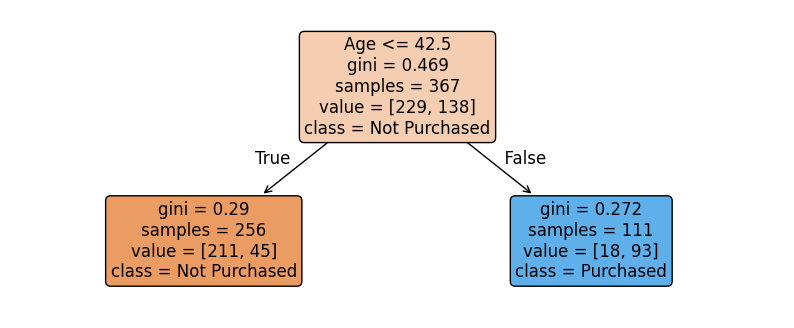

In [201]:
plt.figure(figsize=(10, 4))
plot_tree(dt1, feature_names=['Age', 'EstimatedSalary'], class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True, fontsize=12)
plt.show()

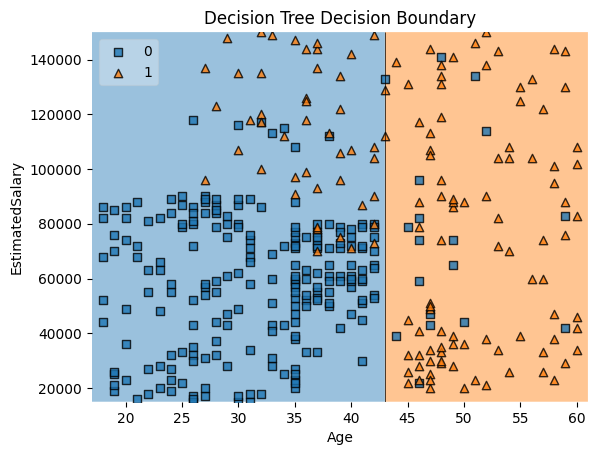

In [202]:
plot_decision_regions(x,y,clf=dt1,legend=2)
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Decision Tree Decision Boundary')
plt.show()

In [203]:
df1['y_pred']=dt1.predict(x)
df1

,Age,EstimatedSalary,Purchased,weights,y_pred
0,19,19000,0,0.002725,0
1,35,20000,0,0.002725,0
2,26,43000,0,0.002725,0
3,27,57000,0,0.002725,0
4,19,76000,0,0.002725,0
...,...,...,...,...,...
362,46,41000,1,0.002725,1
363,51,23000,1,0.002725,1
364,50,20000,1,0.002725,1
365,36,33000,0,0.002725,0


#### Calculate Weighted Error and Model Weight (Alpha 1)
- Error = sum of weights of misclassified samples
- Alpha = 0.5 * ln((1 - error) / error)
- Higher alpha means the stump performed better and gets more voting power

In [204]:
def calculate_error(df):
    error = df.loc[df['Purchased'] != df['y_pred'], 'weights'].sum()
    return error

In [205]:
error_1 = calculate_error(df1)
print(error_1)

0.17166212534059952


In [206]:
def calculate_model_weight(error):
    
    return .5*np.log((1-error)/(error+.00000001))

In [207]:
alpha_1=calculate_model_weight(error_1)
alpha_1

np.float64(0.786946458380361)

#### Update and Normalize Weights
- Correctly classified samples get lower weight: w * exp(-alpha)
- Misclassified samples get higher weight: w * exp(alpha)
- Then normalize so all weights sum to 1
This forces the next stump to focus on the hard examples.

In [208]:
def update_row_weights(row,alpha):
    if row['Purchased']==row['y_pred']:
        return row['weights']*np.exp(-alpha)
    else:
        return row['weights']*np.exp(alpha)

In [209]:
df1['updated_weights'] = df1.apply(lambda row: update_row_weights(row, alpha_1), axis=1)
df1.head()

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights
0,19,19000,0,0.002725,0,0.00124
1,35,20000,0,0.002725,0,0.00124
2,26,43000,0,0.002725,0,0.00124
3,27,57000,0,0.002725,0,0.00124
4,19,76000,0,0.002725,0,0.00124


In [210]:
def normalize_weights(df):
    df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()
    return df

In [211]:
df1 = normalize_weights(df1)
df1

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,normalized_weights
0,19,19000,0,0.002725,0,0.00124,0.001645
1,35,20000,0,0.002725,0,0.00124,0.001645
2,26,43000,0,0.002725,0,0.00124,0.001645
3,27,57000,0,0.002725,0,0.00124,0.001645
4,19,76000,0,0.002725,0,0.00124,0.001645
...,...,...,...,...,...,...,...
362,46,41000,1,0.002725,1,0.00124,0.001645
363,51,23000,1,0.002725,1,0.00124,0.001645
364,50,20000,1,0.002725,1,0.00124,0.001645
365,36,33000,0,0.002725,0,0.00124,0.001645


In [212]:
df1['normalized_weights'].sum()

np.float64(1.0)

#### Weighted Sampling using Cumulative Sum
We create a new dataset by sampling with replacement using normalized weights.
Samples with higher weights are more likely to be picked — this is how AdaBoost focuses on mistakes.

In [213]:
def calculate_cumsum(df):
    df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
    df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']
    return df

In [214]:
df1 = calculate_cumsum(df1)

In [215]:
def show_df(df):
    return df[['Age', 'EstimatedSalary', 'Purchased', 'weights', 
               'y_pred', 'updated_weights', 'cumsum_lower', 'cumsum_upper']]

In [216]:
show_df(df1)

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,19,19000,0,0.002725,0,0.00124,0.000000,0.001645
1,35,20000,0,0.002725,0,0.00124,0.001645,0.003289
2,26,43000,0,0.002725,0,0.00124,0.003289,0.004934
3,27,57000,0,0.002725,0,0.00124,0.004934,0.006579
4,19,76000,0,0.002725,0,0.00124,0.006579,0.008224
...,...,...,...,...,...,...,...,...
362,46,41000,1,0.002725,1,0.00124,0.991776,0.993421
363,51,23000,1,0.002725,1,0.00124,0.993421,0.995066
364,50,20000,1,0.002725,1,0.00124,0.995066,0.996711
365,36,33000,0,0.002725,0,0.00124,0.996711,0.998355


#### Creating New Dataset

In [217]:
def create_new_dataset(df):
    indices=[]

    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper']>a and a>row['cumsum_lower']:
                indices.append(index)
    return indices            

In [218]:
index_values_1 = create_new_dataset(df1)
len(index_values_1)

367

In [219]:
df2 = df1.iloc[index_values_1,[0,1,2,3]]
df2

,Age,EstimatedSalary,Purchased,weights
333,43,129000,1,0.002725
277,42,73000,1,0.002725
219,35,147000,1,0.002725
252,43,133000,0,0.002725
149,46,59000,0,0.002725
...,...,...,...,...
255,39,106000,1,0.002725
235,35,97000,1,0.002725
225,46,82000,0,0.002725
286,42,54000,0,0.002725


#### Train Second Weak Learner (Decision Stump 2)
Trained on the resampled dataset where previously misclassified points appear more often.

In [220]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [221]:
x = df2.iloc[:,0:2].values
y = df2.iloc[:,2].values

In [222]:
dt2.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

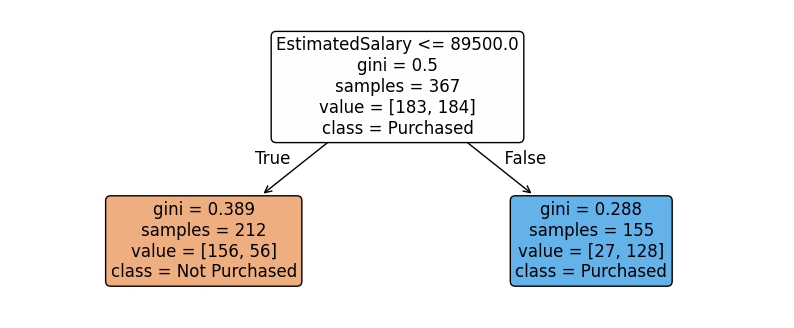

In [223]:
plt.figure(figsize=(10, 4))
plot_tree(dt2, feature_names=['Age', 'EstimatedSalary'], class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True, fontsize=12)
plt.show()

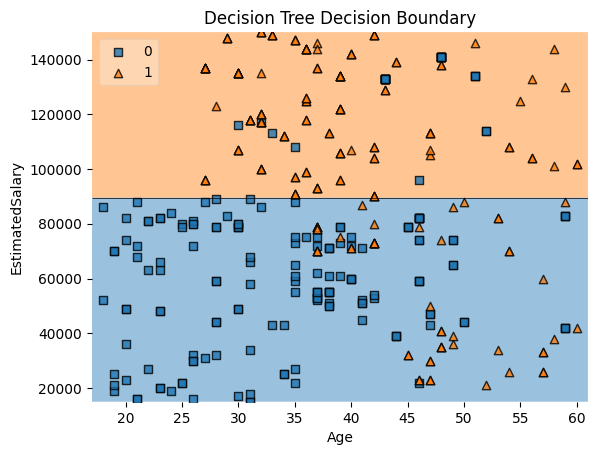

In [224]:
plot_decision_regions(x,y,clf=dt2,legend=2)
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Decision Tree Decision Boundary')
plt.show()

In [225]:
df2['y_pred']=dt2.predict(x)
df2

,Age,EstimatedSalary,Purchased,weights,y_pred
333,43,129000,1,0.002725,1
277,42,73000,1,0.002725,0
219,35,147000,1,0.002725,1
252,43,133000,0,0.002725,1
149,46,59000,0,0.002725,0
...,...,...,...,...,...
255,39,106000,1,0.002725,1
235,35,97000,1,0.002725,1
225,46,82000,0,0.002725,0
286,42,54000,0,0.002725,0


In [226]:
error_2= calculate_error(df2)

In [227]:
alpha_2 = calculate_model_weight(error_2)
alpha_2

np.float64(0.6150667930738709)

In [228]:
df2['updated_weights'] = df2.apply(lambda row: update_row_weights(row, alpha_2),axis=1)
df2

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights
333,43,129000,1,0.002725,1,0.001473
277,42,73000,1,0.002725,0,0.005040
219,35,147000,1,0.002725,1,0.001473
252,43,133000,0,0.002725,1,0.005040
149,46,59000,0,0.002725,0,0.001473
...,...,...,...,...,...,...
255,39,106000,1,0.002725,1,0.001473
235,35,97000,1,0.002725,1,0.001473
225,46,82000,0,0.002725,0,0.001473
286,42,54000,0,0.002725,0,0.001473


In [229]:
df2 = normalize_weights(df2)
df2

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,normalized_weights
333,43,129000,1,0.002725,1,0.001473,0.001761
277,42,73000,1,0.002725,0,0.005040,0.006024
219,35,147000,1,0.002725,1,0.001473,0.001761
252,43,133000,0,0.002725,1,0.005040,0.006024
149,46,59000,0,0.002725,0,0.001473,0.001761
...,...,...,...,...,...,...,...
255,39,106000,1,0.002725,1,0.001473,0.001761
235,35,97000,1,0.002725,1,0.001473,0.001761
225,46,82000,0,0.002725,0,0.001473,0.001761
286,42,54000,0,0.002725,0,0.001473,0.001761


In [230]:
df2['normalized_weights'].sum()

np.float64(1.0)

In [231]:
calculate_cumsum(df2)
show_df(df2)

,Age,EstimatedSalary,Purchased,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
333,43,129000,1,0.002725,1,0.001473,0.000000,0.001761
277,42,73000,1,0.002725,0,0.005040,0.001761,0.007785
219,35,147000,1,0.002725,1,0.001473,0.007785,0.009545
252,43,133000,0,0.002725,1,0.005040,0.009545,0.015569
149,46,59000,0,0.002725,0,0.001473,0.015569,0.017330
...,...,...,...,...,...,...,...,...
255,39,106000,1,0.002725,1,0.001473,0.991197,0.992958
235,35,97000,1,0.002725,1,0.001473,0.992958,0.994718
225,46,82000,0,0.002725,0,0.001473,0.994718,0.996479
286,42,54000,0,0.002725,0,0.001473,0.996479,0.998239


In [232]:
index_values_2 = create_new_dataset(df2)

In [233]:
df3= df2.iloc[index_values_2,[0,1,2,3]]
df3

,Age,EstimatedSalary,Purchased,weights
80,35,88000,0,0.002725
44,23,20000,0,0.002725
279,45,79000,0,0.002725
245,36,144000,1,0.002725
326,37,75000,0,0.002725
...,...,...,...,...
252,43,133000,0,0.002725
80,35,88000,0,0.002725
80,35,88000,0,0.002725
54,23,48000,0,0.002725


#### Train Third Weak Learner (Decision Stump 3)
Final stump trained on resampled data from round 2.

In [234]:
dt3 = DecisionTreeClassifier(max_depth=1)
x= df3.iloc[:,0:2].values
y= df3.iloc[:,2].values
dt3.fit(x,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

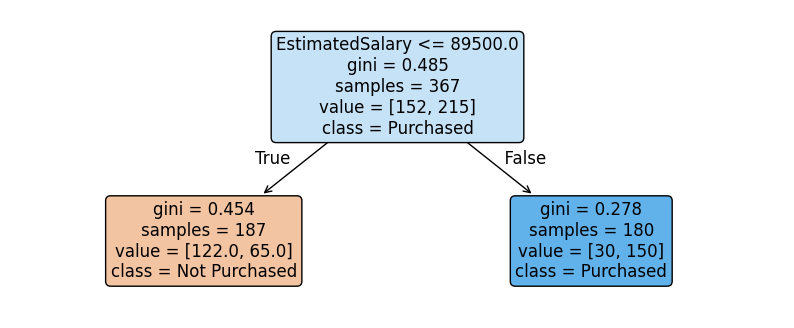

In [235]:
plt.figure(figsize=(10, 4))
plot_tree(dt3, feature_names=['Age', 'EstimatedSalary'], class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True, fontsize=12)
plt.show()

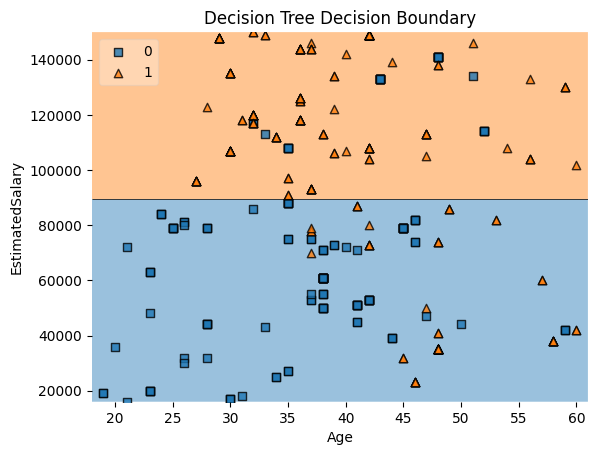

In [236]:
plot_decision_regions(x,y,clf=dt3,legend=2)
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Decision Tree Decision Boundary')
plt.show()

In [237]:
df3['y_pred']=dt3.predict(x)
df3.head()

,Age,EstimatedSalary,Purchased,weights,y_pred
80,35,88000,0,0.002725,0
44,23,20000,0,0.002725,0
279,45,79000,0,0.002725,0
245,36,144000,1,0.002725,1
326,37,75000,0,0.002725,0


In [238]:
error_3= calculate_error(df3)

In [239]:
alpha_3 = calculate_model_weight(error_3)
alpha_3

np.float64(0.5259625680319393)

#### Comparing Alpha Values
Alpha values tell us how much each stump contributes to the final prediction.
A higher alpha = more accurate stump = more voting power.

In [240]:
print(alpha_1,alpha_2,alpha_3)

0.786946458380361 0.6150667930738709 0.5259625680319393


#### Final AdaBoost Prediction
The final prediction is the weighted majority vote of all 3 stumps:
H(x) = sign(alpha_1 * h1(x) + alpha_2 * h2(x) + alpha_3 * h3(x))

In [241]:
def adaboost_predict(age, salary):
    query = np.array([age, salary]).reshape(1, 2)
    
    pred = np.sign(alpha_1 * dt1.predict(query) + alpha_2 * dt2.predict(query) + alpha_3 * dt3.predict(query))
    
    if pred == 1:
        print("Yes — Customer will Purchase")
    else:
        print("No — Customer will NOT Purchase")

In [242]:
adaboost_predict(26,43000)

No — Customer will NOT Purchase


In [243]:
adaboost_predict(45,43000)

Yes — Customer will Purchase


## Conclusion

In this notebook, AdaBoost was implemented from scratch using 3 Decision Stumps on the Social Network Ads dataset.

**Key Takeaways:**
- AdaBoost combines weak learners into one strong classifier
- Misclassified samples get higher weights each round
- Alpha controls each stump's voting power in the final prediction
- Even 3 stumps produce a meaningful decision boundary

**Math Summary:**
- Error:  ε = Σ wᵢ · 𝟙[yᵢ ≠ hₜ(xᵢ)]
- Alpha:  α = 0.5 · ln((1−ε)/ε)
- Final:  H(x) = sign(Σ αₜ · hₜ(x))

---
⭐ If you found this helpful, please  star on GitHub!